# Advertising Sales Prediction
## Linear, Polynomial & Regularized Regression

This project builds a full regression pipeline to predict product sales from advertising spend across TV, radio, and newspaper channels. It progressively explores model complexity — from a simple linear baseline through polynomial feature expansion and into regularized models (Ridge, Lasso, ElasticNet) — comparing each on held-out test performance.

### Dataset

The [Advertising dataset](https://www.kaggle.com/datasets/ashydv/advertising-dataset) contains 200 observations with three spend features (TV, radio, newspaper) and a continuous sales target — all in thousands.

### Workflow

1. **EDA** — visualize spend-vs-sales relationships per channel
2. **Linear Regression** — baseline model; establish benchmark metrics and residual diagnostics
3. **Polynomial Feature Expansion** — capture non-linear and interaction effects; sweep degrees 1–9
4. **Feature Scaling** — StandardScaler applied to polynomial features before regularization
5. **Ridge Regression** — L2 penalty with fixed alpha, then RidgeCV for optimal alpha
6. **Lasso Regression** — L1 penalty with LassoCV for automatic feature selection
7. **ElasticNet** — combined L1+L2 penalty; tuned via ElasticNetCV and GridSearchCV
8. **Model Comparison** — side-by-side MAE/RMSE across all models
9. **Model Persistence** — save and reload best model; predict on a new campaign

### Stack

Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn, SciPy, joblib

---
## Part 1: Setup & Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV, ElasticNet
)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import dump, load

%matplotlib inline
sns.set_style('darkgrid')
pd.set_option('display.max_columns', 20)

In [ ]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Spend vs. Sales — Per Channel

Visualizing the relationship between each advertising channel and sales to identify which channels show the strongest linear signal.

Text(0.5, 1.0, 'NewsPaper spend')

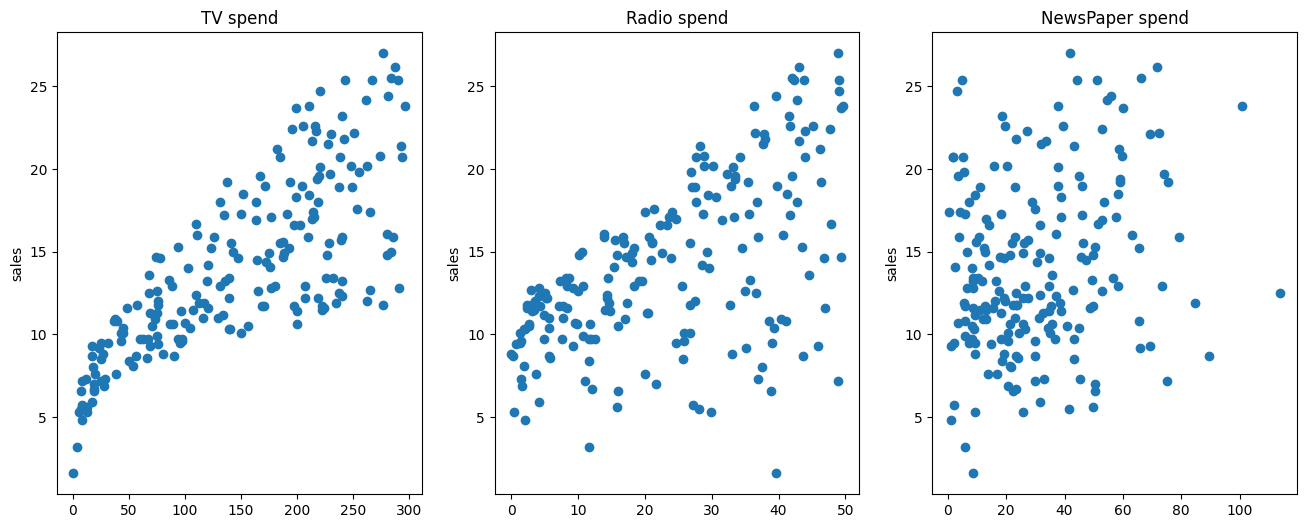

In [ ]:
fig,axes= plt.subplots(nrows=1,ncols=3,figsize=(16,6))
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel('sales')
axes[0].set_title("TV spend")


axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_ylabel('sales')
axes[1].set_title("Radio spend")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_ylabel('sales')
axes[2].set_title("NewsPaper spend")

### Feature / Label Split

In [ ]:
x = df.drop('sales', axis=1)
y = df['sales']

In [ ]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [ ]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

---
## Part 2: Linear Regression — Baseline

A multiple linear regression model using raw features establishes benchmark performance metrics. The residual diagnostics (scatter plot, distribution, Q-Q plot) validate the assumption that errors are roughly normally distributed and homoscedastic.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print('Feature coefficients:')
for feat, coef in zip(x.columns, linear_model.coef_):
    print(f'  {feat:>12}: {coef:.4f}')

### Metrics

In [ ]:
test_pred = linear_model.predict(x_test)

lin_MAE  = mean_absolute_error(y_test, test_pred)
lin_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))
lin_R2   = r2_score(y_test, test_pred)

print(f'Linear Regression  |  MAE: {lin_MAE:.4f}  |  RMSE: {lin_RMSE:.4f}  |  R²: {lin_R2:.4f}')

### Residual Diagnostics

In [ ]:
test_residuals= y_test- test_pred
test_residuals

95     0.334604
15     1.211772
30    -0.151071
158   -3.589238
128    2.497680
115   -0.755569
69     1.103075
170    1.049715
174   -1.775471
45    -0.224495
66     0.485570
182    2.174572
165   -2.402060
78    -3.670260
186    0.843204
177   -0.304544
56    -3.415494
152    0.443807
82     1.004171
68     0.175264
124   -0.068218
16    -1.274690
148   -1.596389
93     0.664982
65     1.691393
60     2.488020
84     0.782405
67     1.593723
125    1.519234
132   -2.814120
9     -1.576049
18     1.330806
55     1.969910
75    -4.077706
150   -2.001136
104    0.624092
135   -2.662026
137   -0.138265
164    1.060612
76     2.518094
79     1.486676
197    0.395137
38    -0.070454
24     1.609186
122   -1.563884
195    2.375645
29     1.211062
19     0.506693
143    1.709755
86     0.338802
114   -1.118484
173    0.068431
5     -6.153607
126   -4.553147
117    3.063632
73     1.238420
140    1.480429
98     1.144835
172   -0.095191
96    -0.453176
Name: sales, dtype: float64

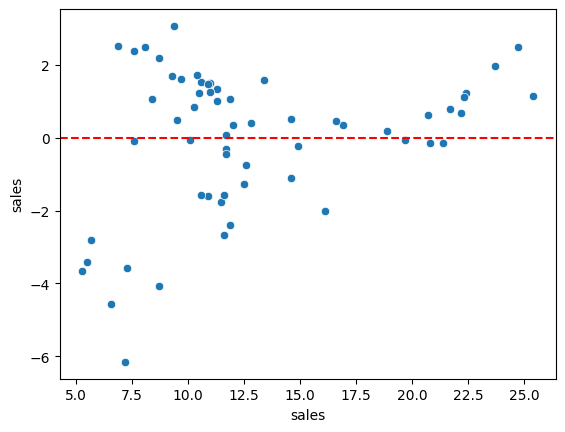

In [ ]:
sns.scatterplot(x=y_test,y= test_residuals)
plt.axhline(y=0,color='r',ls='--')

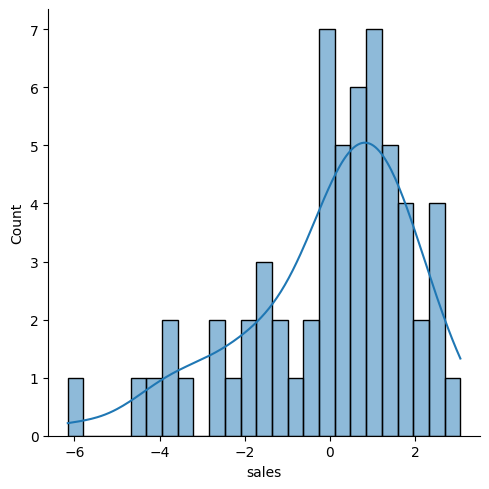

In [ ]:
sns.displot(test_residuals,bins=25,kde=True)

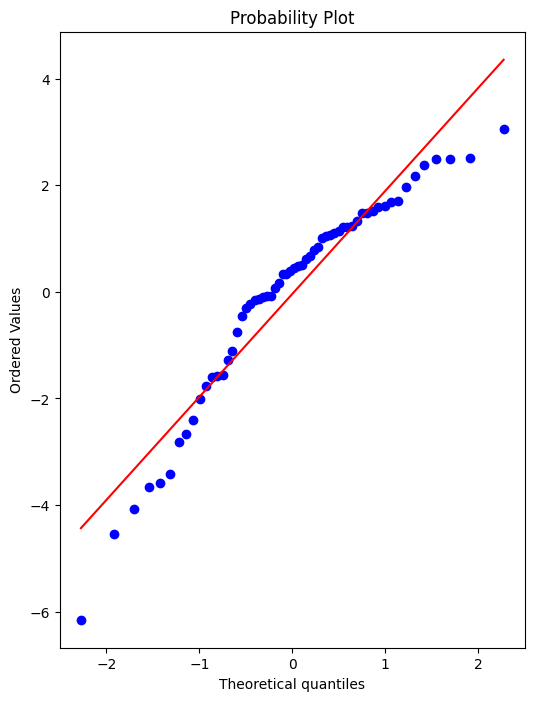

In [ ]:
import scipy as sp

fig,axes= plt.subplots(figsize=(6,8),dpi=100)
_ = sp.stats.probplot(test_residuals,plot=axes)


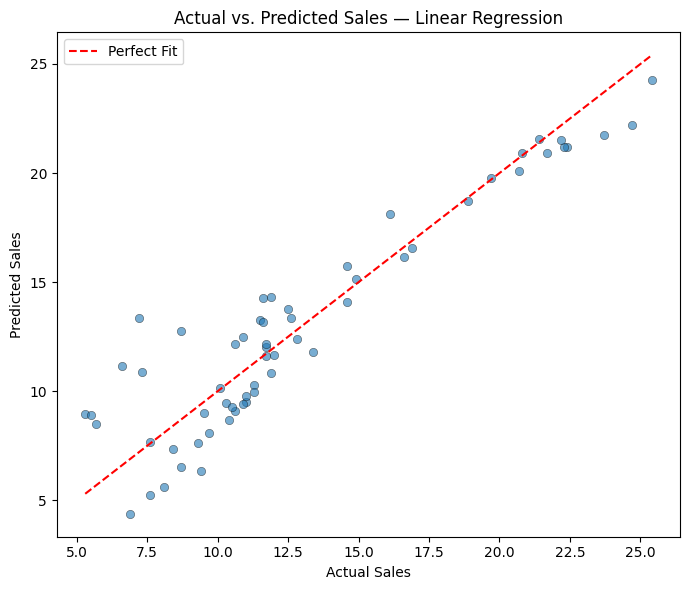

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales — Linear Regression')
plt.legend()
plt.tight_layout()

---
## Part 3: Polynomial Feature Expansion

TV and radio spend have a known interaction effect on sales — combined spend tends to outperform what either channel predicts in isolation. `PolynomialFeatures` generates squared terms and all pairwise interaction terms, expanding the 3-feature input into 9 features at degree 2 (19 at degree 3).

A degree sweep from 1–9 is used to identify where test RMSE bottoms out before overfitting sets in.

### Degree Selection — Train/Test RMSE Sweep

In [ ]:
train_rmse_errors= []
test_rmse_errors=[]

for d in range(1,10):
    poly_conv= PolynomialFeatures(degree=d,include_bias=False)
    poly_features= poly_conv.fit_transform(x)
    X_train,X_test,Y_train,Y_test= train_test_split(poly_features,y,test_size=0.3,random_state=101)
    model= LinearRegression()
    model.fit(X_train,Y_train)
    
    train_pred= model.predict(X_train)
    test_pred= model.predict(X_test)
    
    train_rmse= np.sqrt(mean_squared_error(Y_train,train_pred))
    test_rmse= np.sqrt(mean_squared_error(Y_test,test_pred))
    
    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)
    
    
    
    

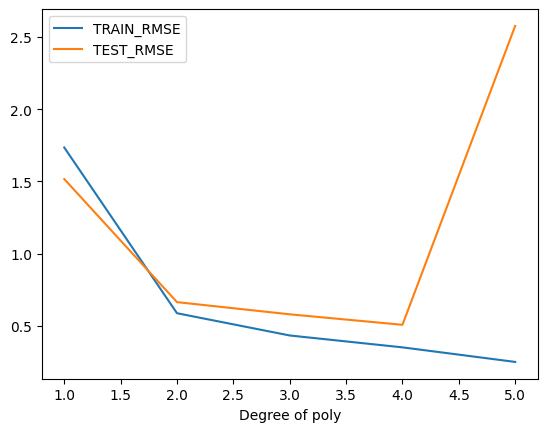

In [ ]:
plt.plot(range(1,6),train_rmse_errors[:5],label= 'TRAIN_RMSE')
plt.plot(range(1,6),test_rmse_errors[:5],label= 'TEST_RMSE')
plt.xlabel('Degree of poly')
plt.legend()

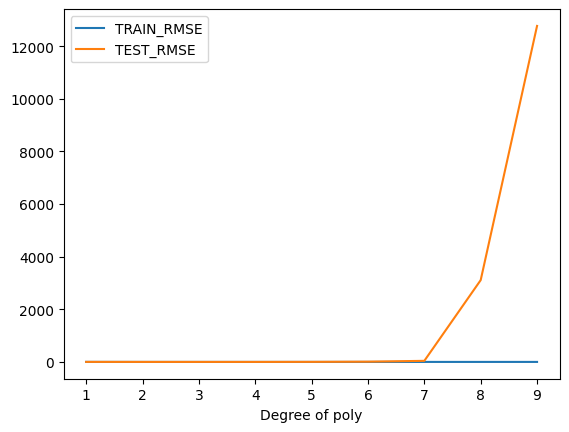

In [ ]:
plt.plot(range(1,10),train_rmse_errors,label= 'TRAIN_RMSE')
plt.plot(range(1,10),test_rmse_errors,label= 'TEST_RMSE')
plt.xlabel('Degree of poly')
plt.legend()

Degree 3 is selected — test RMSE is minimized and the gap between train and test RMSE is still small, indicating the model generalizes well without significant overfitting.

### Fit Polynomial Degree 3 Model

In [ ]:
poly_converter = PolynomialFeatures(degree=3, include_bias=False)
poly_features  = poly_converter.fit_transform(x)

print(f'Original features: {x.shape[1]}  →  Polynomial features: {poly_features.shape[1]}')

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
poly_pred = poly_model.predict(X_test)
test_res   = Y_test - poly_pred

poly_MAE  = mean_absolute_error(Y_test, poly_pred)
poly_RMSE = np.sqrt(mean_squared_error(Y_test, poly_pred))
poly_R2   = r2_score(Y_test, poly_pred)

print(f'Polynomial (deg=3)  |  MAE: {poly_MAE:.4f}  |  RMSE: {poly_RMSE:.4f}  |  R²: {poly_R2:.4f}')

### Residual Diagnostics — Polynomial Model

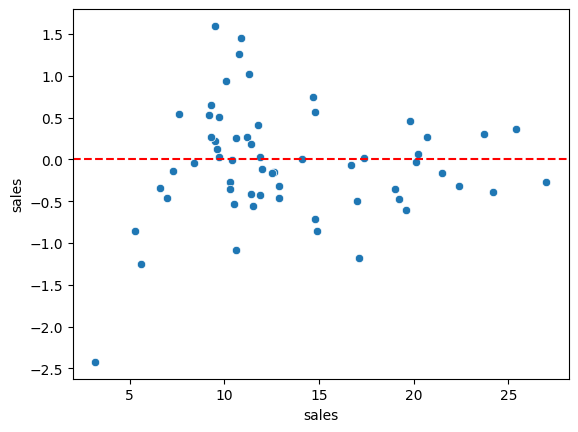

In [ ]:
sns.scatterplot(x=Y_test,y= test_res)
plt.axhline(y=0,color='r',ls='--')

Text(0.5, 1.0, 'Polynomial Model — Residual Distribution')

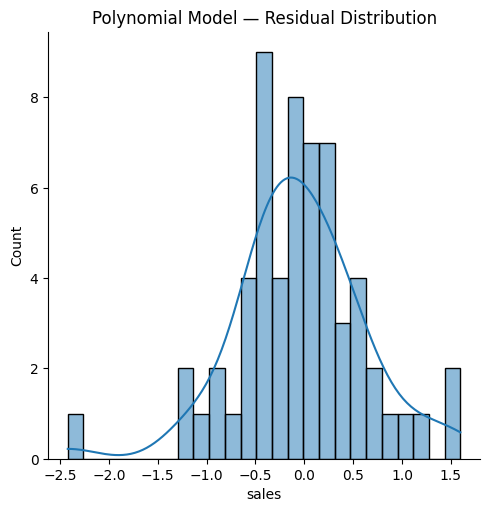

In [ ]:
sns.displot(test_res, bins=25, kde=True)
plt.title('Polynomial Model — Residual Distribution')

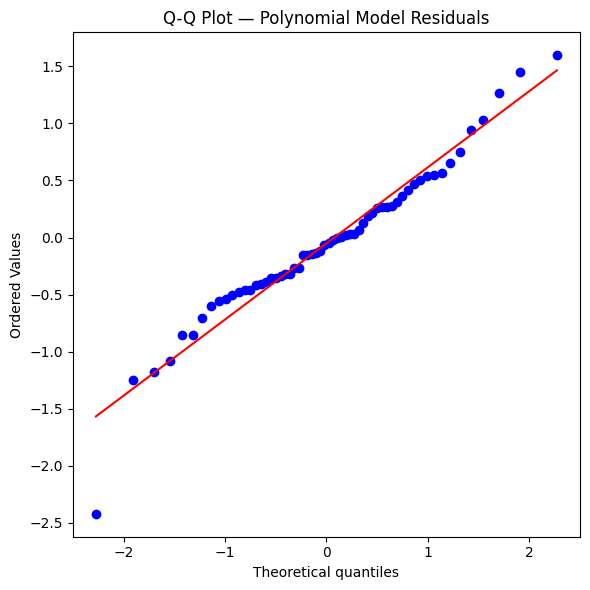

In [ ]:
import scipy as sp

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
_ = sp.stats.probplot(test_res, plot=ax)
ax.set_title('Q-Q Plot — Polynomial Model Residuals')
plt.tight_layout()

---
## Part 4: Feature Scaling

Regularized models are sensitive to feature magnitude — a coefficient on a large-scale feature will be penalized more heavily than one on a small-scale feature, regardless of its true importance. StandardScaler normalizes each feature to zero mean and unit variance.

**Important:** the scaler is fit **only on training data** to prevent data leakage. The same fitted scaler is then applied to transform the test set.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
print(f'X_train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'X_train std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}')

---
## Part 5: Ridge Regression (L2 Regularization)

Ridge regression adds an L2 penalty — the sum of squared coefficients — to the loss function. This shrinks all coefficients toward zero, reducing model variance without eliminating features entirely. The `alpha` parameter controls regularization strength: larger alpha = stronger shrinkage.

Two approaches are compared:
- **Fixed alpha** — manually set `alpha=10` as a starting point
- **RidgeCV** — cross-validated alpha selection across a log-spaced grid

### Fixed Alpha

In [ ]:
ridge_model = Ridge(alpha=10)

In [ ]:
ridge_model.fit(X_train_scaled, Y_train)

Ridge(alpha=10)

In [ ]:
test_predictions = ridge_model.predict(X_test_scaled)

In [ ]:
ridge_MAE  = mean_absolute_error(Y_test, test_predictions)
ridge_RMSE = np.sqrt(mean_squared_error(Y_test, test_predictions))
ridge_R2   = r2_score(Y_test, test_predictions)

print(f'Ridge (alpha=10)    |  MAE: {ridge_MAE:.4f}  |  RMSE: {ridge_RMSE:.4f}  |  R²: {ridge_R2:.4f}')

### RidgeCV — Cross-Validated Alpha Selection

In [ ]:
ridge_cv_model = RidgeCV(
    alphas=(0.1, 1.0, 10.0, 100.0),
    scoring='neg_mean_absolute_error'
)
ridge_cv_model.fit(X_train_scaled, Y_train)

RidgeCV(scoring='neg_mean_absolute_error')

In [ ]:
ridge_cv_model.alpha_

0.1

In [ ]:
test_predictions = ridge_cv_model.predict(X_test_scaled)

In [ ]:
ridgecv_MAE  = mean_absolute_error(Y_test, test_predictions)
ridgecv_RMSE = np.sqrt(mean_squared_error(Y_test, test_predictions))
ridgecv_R2   = r2_score(Y_test, test_predictions)

print(f'RidgeCV             |  MAE: {ridgecv_MAE:.4f}  |  RMSE: {ridgecv_RMSE:.4f}  |  R²: {ridgecv_R2:.4f}')

---
## Part 6: Lasso Regression (L1 Regularization)

Lasso adds an L1 penalty — the sum of absolute coefficient values. Unlike Ridge, Lasso can drive coefficients exactly to zero, performing implicit feature selection. This makes it particularly useful in high-dimensional settings where many features are low-signal.

`LassoCV` uses cross-validation to select the optimal alpha from a regularization path, controlling the granularity of the search with `eps` (ratio of smallest to largest alpha) and `n_alphas` (number of alphas tested).

In [ ]:
lasso_cv_model = LassoCV(eps=0.1, n_alphas=100, cv=5, max_iter=10000)
lasso_cv_model.fit(X_train_scaled, Y_train)

In [ ]:
print(f'Best alpha (LassoCV): {lasso_cv_model.alpha_:.4f}')

LassoCV(cv=5, eps=0.1)

In [ ]:
lasso_cv_model.alpha_

0.4943070909225832

In [ ]:
test_predictions = lasso_cv_model.predict(X_test_scaled)

In [ ]:
lasso_MAE  = mean_absolute_error(Y_test, test_predictions)
lasso_RMSE = np.sqrt(mean_squared_error(Y_test, test_predictions))
lasso_R2   = r2_score(Y_test, test_predictions)

print(f'LassoCV             |  MAE: {lasso_MAE:.4f}  |  RMSE: {lasso_RMSE:.4f}  |  R²: {lasso_R2:.4f}')

### Lasso Coefficients

Zeroed-out coefficients indicate features Lasso identified as low-signal and removed from the model.

In [ ]:
lasso_cv_model.coef_

array([1.002651  , 0.        , 0.        , 0.        , 3.79745279,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

---
## Part 7: ElasticNet (L1 + L2 Regularization)

ElasticNet combines both Ridge and Lasso penalties, controlled by two parameters:
- `alpha` — overall regularization strength
- `l1_ratio` — balance between Lasso (1.0) and Ridge (0.0)

Two tuning strategies are compared:
- **ElasticNetCV** — built-in cross-validation across a grid of l1_ratio values
- **GridSearchCV** — exhaustive search over both alpha and l1_ratio simultaneously

### ElasticNetCV

In [ ]:
elastic_model = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
    tol=0.01,
    cv=5,
    max_iter=10000
)
elastic_model.fit(X_train_scaled, Y_train)

In [ ]:
print(f'Best l1_ratio: {elastic_model.l1_ratio_}')

ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], tol=0.01)

In [ ]:
elastic_model.l1_ratio_

1.0

In [ ]:
test_predictions = elastic_model.predict(X_test_scaled)

In [ ]:
en_cv_MAE  = mean_absolute_error(Y_test, test_predictions)
en_cv_RMSE = np.sqrt(mean_squared_error(Y_test, test_predictions))
en_cv_R2   = r2_score(Y_test, test_predictions)

print(f'ElasticNetCV        |  MAE: {en_cv_MAE:.4f}  |  RMSE: {en_cv_RMSE:.4f}  |  R²: {en_cv_R2:.4f}')

### GridSearchCV — Full Hyperparameter Sweep

In [ ]:
# GridSearchCV — sweep alpha and l1_ratio simultaneously

In [ ]:
base_elastic_net = ElasticNet()

In [ ]:
param_grid = {
    'alpha':    [0.1, 1, 5, 10, 50, 100],
    'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1.0]
}

In [ ]:
grid_model = GridSearchCV(
    estimator=base_elastic_net,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)

In [ ]:
grid_model.fit(X_train_scaled, Y_train)

In [ ]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 0.95}

In [ ]:
grid_pred = grid_model.predict(X_test_scaled)

grid_MAE  = mean_absolute_error(Y_test, grid_pred)
grid_RMSE = np.sqrt(mean_squared_error(Y_test, grid_pred))
grid_R2   = r2_score(Y_test, grid_pred)

print(f'ElasticNet GridCV   |  MAE: {grid_MAE:.4f}  |  RMSE: {grid_RMSE:.4f}  |  R²: {grid_R2:.4f}')

---
## Part 8: Model Comparison

Side-by-side comparison of MAE, RMSE, and R² across all models trained in this project.

In [ ]:
results = pd.DataFrame({
    'Model':  ['Linear', 'Polynomial (deg=3)', 'Ridge (α=10)', 'RidgeCV', 'LassoCV', 'ElasticNetCV', 'ElasticNet GridCV'],
    'MAE':    [lin_MAE,  poly_MAE,  ridge_MAE,  ridgecv_MAE,  lasso_MAE,  en_cv_MAE,  grid_MAE],
    'RMSE':   [lin_RMSE, poly_RMSE, ridge_RMSE, ridgecv_RMSE, lasso_RMSE, en_cv_RMSE, grid_RMSE],
    'R²':     [lin_R2,   poly_R2,   ridge_R2,   ridgecv_R2,   lasso_R2,   en_cv_R2,   grid_R2]
})

results.sort_values('RMSE').round(4)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.sort_values('MAE').plot(x='Model', y='MAE', kind='barh', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('MAE by Model')
axes[0].set_xlabel('MAE')

results.sort_values('RMSE').plot(x='Model', y='RMSE', kind='barh', ax=axes[1], legend=False, color='coral')
axes[1].set_title('RMSE by Model')
axes[1].set_xlabel('RMSE')

plt.tight_layout()

---
## Part 9: Model Persistence & Prediction

The final polynomial + linear model (degree 3) is saved to disk using `joblib`. Both the fitted `PolynomialFeatures` converter and the trained `LinearRegression` model are persisted, so new predictions can be made without re-fitting.

In [ ]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)
full_poly_X = final_poly_converter.fit_transform(x)

final_model = LinearRegression()
final_model.fit(full_poly_X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
dump(final_model, 'final_poly_model.joblib')
dump(final_poly_converter, 'final_poly_converter.joblib')
print('Models saved.')

In [ ]:
loaded_converter = load('final_poly_converter.joblib')
loaded_model     = load('final_poly_model.joblib')

### Predict on a New Campaign

Given a new advertising budget — TV: \$149K, Radio: \$22K, Newspaper: \$12K — predict expected sales using the saved model.

In [ ]:
campaign = [[149, 22, 12]]

In [ ]:
transformed = loaded_converter.fit_transform(campaign)
predicted_sales = loaded_model.predict(transformed)

print(f'Predicted sales: {predicted_sales[0]:.2f} (thousands)')

array([14.64501014])

---

*End of project.*